In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
import time
import matplotlib.pyplot as plt

Problem 1: RNN, LSTM, GRU

In [3]:
text = "Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text. At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model. One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks. Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time. Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants. In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."


In [4]:

# Creating character vocabulary and Dataset
#set(text): Creates a set of unique characters found in the text. The set function removes any duplicate characters.
#list(set(text)): Converts the set back into a list so that it can be sorted.
# sorted(list(set(text))): Sorts the list of unique characters.
chars = sorted(list(set(text)))
#This line creates a dictionary that maps each character to a unique index (integer)."
ix_to_char = {i: ch for i, ch in enumerate(chars)}
#Similar to the previous line, but in reverse. This line creates a dictionary that maps each unique index (integer) back to its corresponding character.
char_to_ix = {ch: i for i, ch in enumerate(chars)}
chars = sorted(list(set(text)))

def prepare_data(text, seq_length):
  # Preparing the dataset
  max_length = seq_length  # Maximum length of input sequences
  X = []
  y = []
  for i in range(len(text) - max_length):
      sequence = text[i:i + max_length]
      label = text[i + max_length]
      X.append([char_to_ix[char] for char in sequence])
      y.append(char_to_ix[label])

  X = np.array(X)
  y = np.array(y)

  # Splitting the dataset into training and validation sets
  X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

  # Converting data to PyTorch tensors
  X_train = torch.tensor(X_train, dtype=torch.long)
  y_train = torch.tensor(y_train, dtype=torch.long)
  X_val = torch.tensor(X_val, dtype=torch.long)
  y_val = torch.tensor(y_val, dtype=torch.long)
  return X_train, y_train, X_val, y_val


In [5]:
# Hyperparameters
hidden_size = 256
learning_rate = 0.005
epochs = 100

def count_parameters(model):
    print(sum(p.numel() for p in model.parameters() if p.requires_grad))

# Prediction function
def predict_next_char(model, char_to_ix, ix_to_char, initial_str, max_length):
    model.eval()
    with torch.no_grad():
        initial_input = torch.tensor([char_to_ix[c] for c in initial_str[-max_length:]], dtype=torch.long).unsqueeze(0)
        prediction = model(initial_input)
        predicted_index = torch.argmax(prediction, dim=1).item()
        return ix_to_char[predicted_index]
def plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies, title="Model"):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Losses on left Y-axis
    ax1.plot(train_losses, label='Train Loss', color='blue')
    ax1.plot(val_losses, label='Val Loss', color='orange')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper left')

    # Plot Accuracies on right Y-axis
    ax2 = ax1.twinx()
    ax2.plot(train_accuracies, label='Train Accuracy', color='purple', linestyle='dashed') # NEW: Plotting Train Acc
    ax2.plot(val_accuracies, label='Val Accuracy', color='green', linestyle='dashed')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend(loc='upper right')

    plt.title(f'{title} - Training Metrics')
    plt.grid(True)
    plt.show()

def train(model, criterion, optimizer, X_train, y_train, X_val, y_val, epochs, seq_length):
  # Training the model
    print(f"{model.name} Model with {seq_length} Sequence Length")
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    epoch_times = [] # Keep track of time per epoch
    for epoch in range(epochs):
        start_time = time.time()
        # Training
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(output, 1)
        train_accuracy = (predicted == y_train).float().mean()
        end_time = time.time()
        epoch_duration = end_time - start_time
        epoch_times.append(epoch_duration)
        # Validation
        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = criterion(val_output, y_val)
            #The use of the underscore _ is a common Python convention to indicate that the actual maximum values returned by torch.max are not needed and can be disregarded.
            #What we are interested in is the indices of these maximum values, which are captured by the variable predicted. These indices represent the model's predictions for each example in the validation set.
            _, predicted = torch.max(val_output, 1)
            val_accuracy = (predicted == y_val).float().mean()
            train_losses.append(loss.item())
            val_losses.append(val_loss.item())
            train_accuracies.append(train_accuracy.item())
            val_accuracies.append(val_accuracy.item())
            print(f'Epoch {epoch+1}/{epochs}| Time: {epoch_duration:.2f}s| Training Loss: {loss.item():.4f}| Training Accuracy: {train_accuracy.item():.4f}| Validation Loss: {val_loss.item():.4f}| Validation Accuracy: {val_accuracy.item():.4f}')
    Average_Time = sum(epoch_times) / len(epoch_times)
    print(f"Average time per epoch: {Average_Time:.2f} seconds")
    test_str = "This is a simple example to demonstrate how to predict the next char"
    predicted_char = predict_next_char(model, char_to_ix, ix_to_char, test_str,seq_length)
    print(f"Predicted next character: '{predicted_char}'")
    plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies, f"{model.name} with {x} Training Epochs")



154156
RNN Model with 10 Sequence Length
Epoch 1/100| Time: 0.06s| Training Loss: 3.8001| Training Accuracy: 0.0221| Validation Loss: 2.9360| Validation Accuracy: 0.3550
Epoch 2/100| Time: 0.05s| Training Loss: 2.9336| Training Accuracy: 0.3305| Validation Loss: 2.5123| Validation Accuracy: 0.3382
Epoch 3/100| Time: 0.04s| Training Loss: 2.5390| Training Accuracy: 0.3100| Validation Loss: 2.4283| Validation Accuracy: 0.2878
Epoch 4/100| Time: 0.05s| Training Loss: 2.3973| Training Accuracy: 0.3126| Validation Loss: 2.3104| Validation Accuracy: 0.3424
Epoch 5/100| Time: 0.05s| Training Loss: 2.2315| Training Accuracy: 0.3784| Validation Loss: 2.2587| Validation Accuracy: 0.3887
Epoch 6/100| Time: 0.05s| Training Loss: 2.1386| Training Accuracy: 0.4074| Validation Loss: 2.2106| Validation Accuracy: 0.4013
Epoch 7/100| Time: 0.04s| Training Loss: 2.0443| Training Accuracy: 0.4232| Validation Loss: 2.1821| Validation Accuracy: 0.3929
Epoch 8/100| Time: 0.04s| Training Loss: 1.9617| Trainin

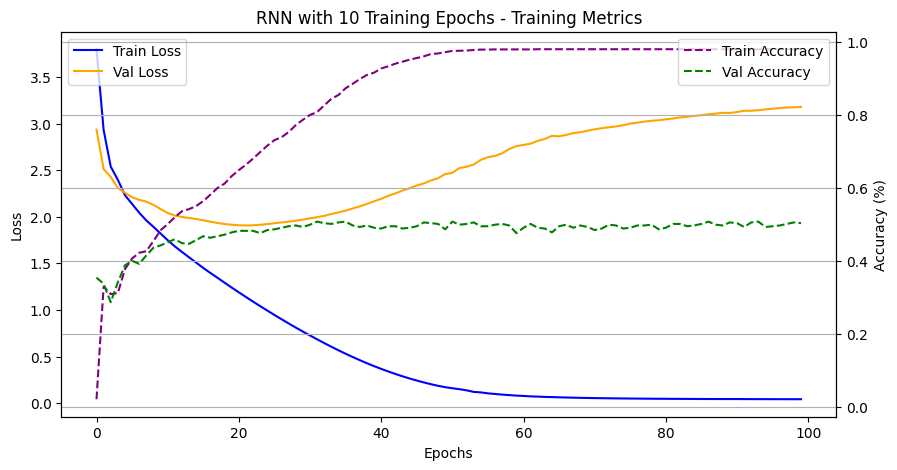

154156
RNN Model with 20 Sequence Length
Epoch 1/100| Time: 0.12s| Training Loss: 3.8256| Training Accuracy: 0.0307| Validation Loss: 3.0267| Validation Accuracy: 0.2764
Epoch 2/100| Time: 0.11s| Training Loss: 2.9658| Training Accuracy: 0.2992| Validation Loss: 2.6018| Validation Accuracy: 0.2932
Epoch 3/100| Time: 0.11s| Training Loss: 2.5697| Training Accuracy: 0.3103| Validation Loss: 2.4637| Validation Accuracy: 0.3186
Epoch 4/100| Time: 0.11s| Training Loss: 2.4017| Training Accuracy: 0.3155| Validation Loss: 2.3801| Validation Accuracy: 0.3544
Epoch 5/100| Time: 0.13s| Training Loss: 2.2826| Training Accuracy: 0.3547| Validation Loss: 2.2946| Validation Accuracy: 0.3966
Epoch 6/100| Time: 0.12s| Training Loss: 2.1625| Training Accuracy: 0.3922| Validation Loss: 2.2386| Validation Accuracy: 0.3861
Epoch 7/100| Time: 0.12s| Training Loss: 2.0721| Training Accuracy: 0.3996| Validation Loss: 2.2038| Validation Accuracy: 0.4008
Epoch 8/100| Time: 0.11s| Training Loss: 1.9990| Trainin

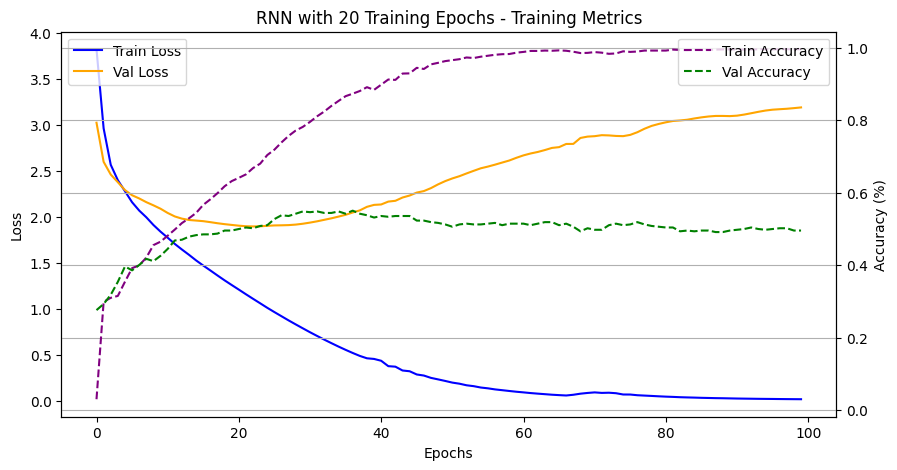

154156
RNN Model with 30 Sequence Length
Epoch 1/100| Time: 0.16s| Training Loss: 3.8307| Training Accuracy: 0.0207| Validation Loss: 3.1036| Validation Accuracy: 0.2712
Epoch 2/100| Time: 0.17s| Training Loss: 2.9588| Training Accuracy: 0.3100| Validation Loss: 2.6888| Validation Accuracy: 0.2648
Epoch 3/100| Time: 0.19s| Training Loss: 2.5477| Training Accuracy: 0.2887| Validation Loss: 2.5585| Validation Accuracy: 0.3030
Epoch 4/100| Time: 0.17s| Training Loss: 2.3859| Training Accuracy: 0.3402| Validation Loss: 2.4745| Validation Accuracy: 0.3157
Epoch 5/100| Time: 0.17s| Training Loss: 2.2554| Training Accuracy: 0.3769| Validation Loss: 2.3882| Validation Accuracy: 0.3369
Epoch 6/100| Time: 0.18s| Training Loss: 2.1380| Training Accuracy: 0.4018| Validation Loss: 2.3241| Validation Accuracy: 0.3665
Epoch 7/100| Time: 0.17s| Training Loss: 2.0495| Training Accuracy: 0.4236| Validation Loss: 2.2757| Validation Accuracy: 0.3941
Epoch 8/100| Time: 0.17s| Training Loss: 1.9658| Trainin

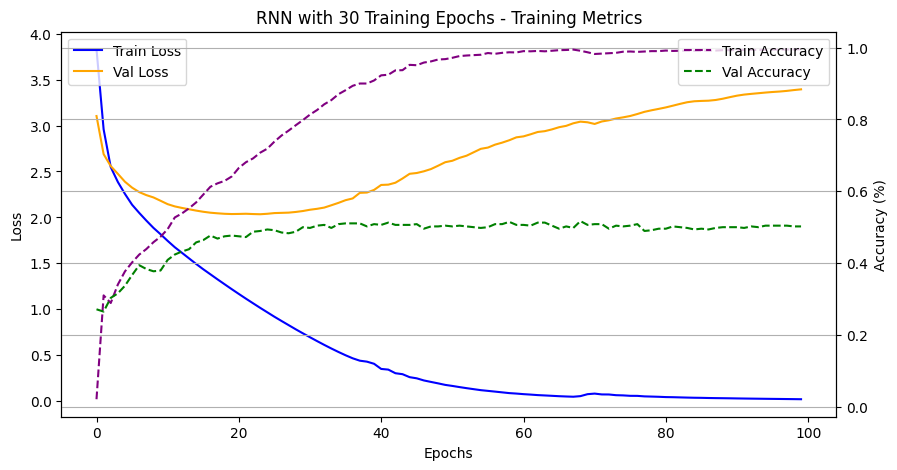

In [15]:
# Defining the RNN model
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        #This line takes the input tensor x, which contains indices of characters, and passes it through an embedding layer (self.embedding).
        #The embedding layer converts these indices into dense vectors of fixed size.
        #These vectors are learned during training and can capture semantic similarities between characters.
        #The result is a higher-dimensional representation of the input sequence, where each character index is replaced by its corresponding embedding vector.
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        #The RNN layer returns two outputs:
        #1- the output tensor containing the output of the RNN at each time step for each sequence in the batch,
        #2-the hidden state (_) of the last time step (which is not used in this line, hence the underscore).
        output, _ = self.rnn(embedded)
        #The RNN's output contains the outputs for every time step,
        #but for this task, we're only interested in the output of the last time step because we're predicting the next character after the sequence.
        #output[:, -1, :] selects the last time step's output for every sequence in the batch (-1 indexes the last item in Python).
        output = self.fc(output[:, -1, :])  # Get the output of the last RNN cell
        return output

# Hyperparameters
hidden_size = 256
learning_rate = 0.005
epochs = 100

def count_parameters(model):
    print(sum(p.numel() for p in model.parameters() if p.requires_grad))

# Prediction function
def predict_next_char(model, char_to_ix, ix_to_char, initial_str, seq_length):
    model.eval()
    with torch.no_grad():
        initial_input = torch.tensor([char_to_ix[c] for c in initial_str[-seq_length:]], dtype=torch.long).unsqueeze(0)
        prediction = model(initial_input)
        predicted_index = torch.argmax(prediction, dim=1).item()
        return ix_to_char[predicted_index]

def plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies, title="Model"):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Losses on left Y-axis
    ax1.plot(train_losses, label='Train Loss', color='blue')
    ax1.plot(val_losses, label='Val Loss', color='orange')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='upper left')

    # Plot Accuracies on right Y-axis
    ax2 = ax1.twinx()
    ax2.plot(train_accuracies, label='Train Accuracy', color='purple', linestyle='dashed') # NEW: Plotting Train Acc
    ax2.plot(val_accuracies, label='Val Accuracy', color='green', linestyle='dashed')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend(loc='upper right')

    plt.title(f'{title} - Training Metrics')
    plt.grid(True)
    plt.show()

def train(model, criterion, optimizer, X_train, y_train, X_val, y_val, epochs, seq_length):
  # Training the model
    print(f"{model.name} Model with {seq_length} Sequence Length")
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    epoch_times = [] # Keep track of time per epoch
    for epoch in range(epochs):
        start_time = time.time()
        # Training
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(output, 1)
        train_accuracy = (predicted == y_train).float().mean()
        end_time = time.time()
        epoch_duration = end_time - start_time
        epoch_times.append(epoch_duration)
        # Validation
        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = criterion(val_output, y_val)
            #The use of the underscore _ is a common Python convention to indicate that the actual maximum values returned by torch.max are not needed and can be disregarded.
            #What we are interested in is the indices of these maximum values, which are captured by the variable predicted. These indices represent the model's predictions for each example in the validation set.
            _, predicted = torch.max(val_output, 1)
            val_accuracy = (predicted == y_val).float().mean()
            train_losses.append(loss.item())
            val_losses.append(val_loss.item())
            train_accuracies.append(train_accuracy.item())
            val_accuracies.append(val_accuracy.item())
            print(f'Epoch {epoch+1}/{epochs}| Time: {epoch_duration:.2f}s| Training Loss: {loss.item():.4f}| Training Accuracy: {train_accuracy.item():.4f}| Validation Loss: {val_loss.item():.4f}| Validation Accuracy: {val_accuracy.item():.4f}')
    Average_Time = sum(epoch_times) / len(epoch_times)
    print(f"Average time per epoch: {Average_Time:.2f} seconds")
    test_str = "This is a simple example to demonstrate how to predict the next char"
    predicted_char = predict_next_char(model, char_to_ix, ix_to_char, test_str,seq_length)
    print(f"Predicted next character: '{predicted_char}'")
    plot_metrics(train_losses, train_accuracies, val_losses, val_accuracies, f"{model.name} with {x} Training Epochs")



# Predicting the next character
seq_length = [10, 20, 30]
for x in seq_length:
  model = CharRNN(len(chars), hidden_size, len(chars))
  model.name = "RNN"
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  count_parameters(model)
  X_train, y_train, X_val, y_val = prepare_data(text, x)
  train(model, criterion, optimizer, X_train, y_train, X_val, y_val, epochs, x)

548908
LSTM Model with 10 Sequence Length
Epoch 1/100| Time: 0.31s| Training Loss: 3.7771| Training Accuracy: 0.0374| Validation Loss: 3.3416| Validation Accuracy: 0.2773
Epoch 2/100| Time: 0.20s| Training Loss: 3.3589| Training Accuracy: 0.2611| Validation Loss: 2.8354| Validation Accuracy: 0.2542
Epoch 3/100| Time: 0.18s| Training Loss: 2.8849| Training Accuracy: 0.2395| Validation Loss: 2.6813| Validation Accuracy: 0.2521
Epoch 4/100| Time: 0.19s| Training Loss: 2.7483| Training Accuracy: 0.2453| Validation Loss: 2.5219| Validation Accuracy: 0.3025
Epoch 5/100| Time: 0.18s| Training Loss: 2.5439| Training Accuracy: 0.3053| Validation Loss: 2.4047| Validation Accuracy: 0.3613
Epoch 6/100| Time: 0.19s| Training Loss: 2.4021| Training Accuracy: 0.3521| Validation Loss: 2.3385| Validation Accuracy: 0.3866
Epoch 7/100| Time: 0.20s| Training Loss: 2.3136| Training Accuracy: 0.3689| Validation Loss: 2.2829| Validation Accuracy: 0.3908
Epoch 8/100| Time: 0.18s| Training Loss: 2.2279| Traini

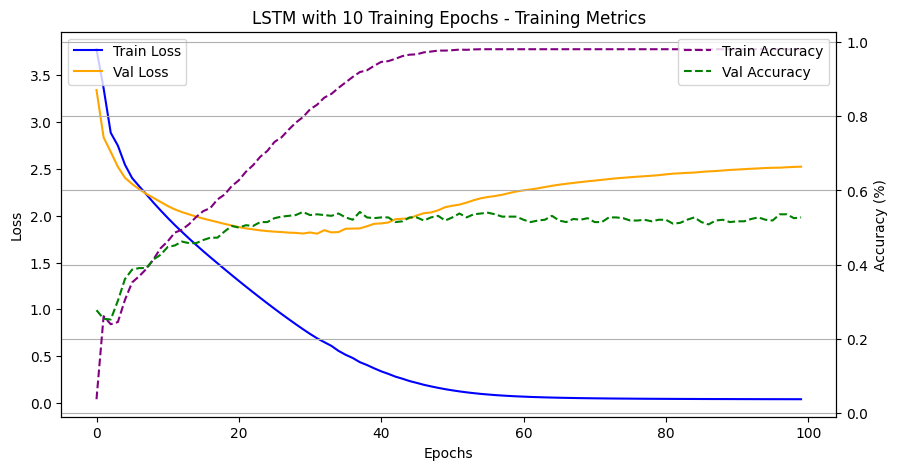

548908
LSTM Model with 20 Sequence Length
Epoch 1/100| Time: 0.38s| Training Loss: 3.7879| Training Accuracy: 0.0275| Validation Loss: 3.3748| Validation Accuracy: 0.2511
Epoch 2/100| Time: 0.38s| Training Loss: 3.3611| Training Accuracy: 0.2516| Validation Loss: 2.9071| Validation Accuracy: 0.2215
Epoch 3/100| Time: 0.39s| Training Loss: 2.9045| Training Accuracy: 0.2072| Validation Loss: 2.7177| Validation Accuracy: 0.2553
Epoch 4/100| Time: 0.38s| Training Loss: 2.7351| Training Accuracy: 0.2553| Validation Loss: 2.5803| Validation Accuracy: 0.2996
Epoch 5/100| Time: 0.38s| Training Loss: 2.5722| Training Accuracy: 0.3103| Validation Loss: 2.4707| Validation Accuracy: 0.3439
Epoch 6/100| Time: 0.39s| Training Loss: 2.4382| Training Accuracy: 0.3457| Validation Loss: 2.3861| Validation Accuracy: 0.3544
Epoch 7/100| Time: 0.38s| Training Loss: 2.3322| Training Accuracy: 0.3726| Validation Loss: 2.3193| Validation Accuracy: 0.3650
Epoch 8/100| Time: 0.39s| Training Loss: 2.2404| Traini

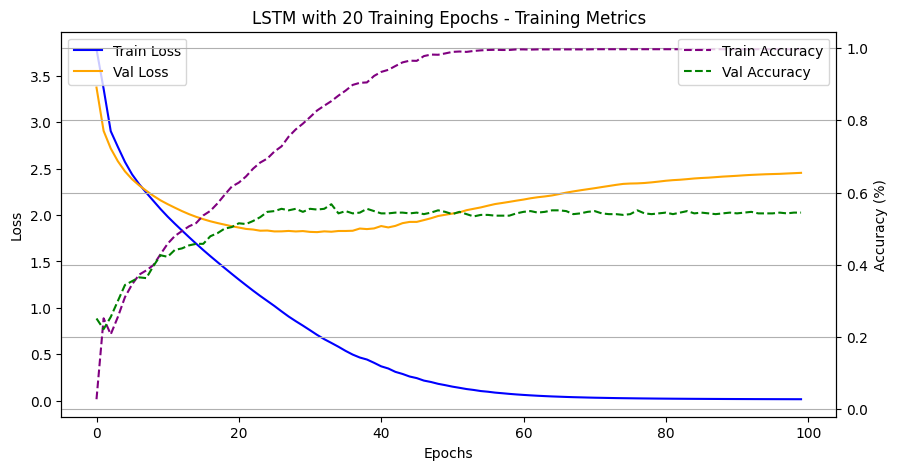

548908
LSTM Model with 30 Sequence Length
Epoch 1/100| Time: 0.73s| Training Loss: 3.7997| Training Accuracy: 0.0212| Validation Loss: 3.4165| Validation Accuracy: 0.2564
Epoch 2/100| Time: 0.73s| Training Loss: 3.3854| Training Accuracy: 0.2861| Validation Loss: 2.9206| Validation Accuracy: 0.2373
Epoch 3/100| Time: 0.56s| Training Loss: 2.8891| Training Accuracy: 0.2404| Validation Loss: 2.8019| Validation Accuracy: 0.2542
Epoch 4/100| Time: 0.57s| Training Loss: 2.7819| Training Accuracy: 0.2447| Validation Loss: 2.6630| Validation Accuracy: 0.2606
Epoch 5/100| Time: 0.56s| Training Loss: 2.5947| Training Accuracy: 0.3079| Validation Loss: 2.5532| Validation Accuracy: 0.2860
Epoch 6/100| Time: 0.58s| Training Loss: 2.4553| Training Accuracy: 0.3323| Validation Loss: 2.4734| Validation Accuracy: 0.3347
Epoch 7/100| Time: 0.57s| Training Loss: 2.3553| Training Accuracy: 0.3636| Validation Loss: 2.4039| Validation Accuracy: 0.3517
Epoch 8/100| Time: 0.56s| Training Loss: 2.2661| Traini

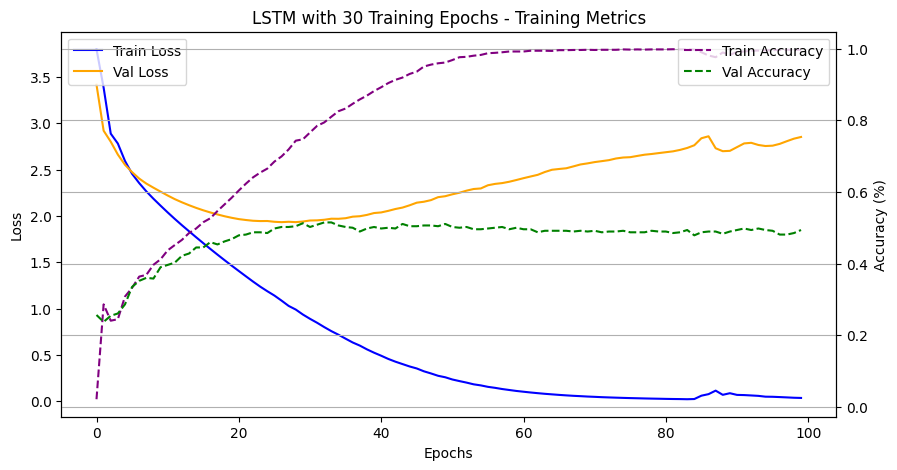

In [16]:
# Defining the RNN model
class CharLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharLSTM, self).__init__()
        self.hidden_size = hidden_size
        #This line takes the input tensor x, which contains indices of characters, and passes it through an embedding layer (self.embedding).
        #The embedding layer converts these indices into dense vectors of fixed size.
        #These vectors are learned during training and can capture semantic similarities between characters.
        #The result is a higher-dimensional representation of the input sequence, where each character index is replaced by its corresponding embedding vector.
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        #The RNN layer returns two outputs:
        #1- the output tensor containing the output of the RNN at each time step for each sequence in the batch,
        #2-the hidden state (_) of the last time step (which is not used in this line, hence the underscore).
        output, _ = self.rnn(embedded)
        #The RNN's output contains the outputs for every time step,
        #but for this task, we're only interested in the output of the last time step because we're predicting the next character after the sequence.
        #output[:, -1, :] selects the last time step's output for every sequence in the batch (-1 indexes the last item in Python).
        output = self.fc(output[:, -1, :])  # Get the output of the last RNN cell
        return output
for x in seq_length:
  model = CharLSTM(len(chars), hidden_size, len(chars))
  model.name = "LSTM"
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  count_parameters(model)
  X_train, y_train, X_val, y_val = prepare_data(text, x)
  train(model, criterion, optimizer, X_train, y_train, X_val, y_val, epochs, x)

417324
GRU Model with 10 Sequence Length
Epoch 1/100| Time: 0.14s| Training Loss: 3.7813| Training Accuracy: 0.0316| Validation Loss: 3.0537| Validation Accuracy: 0.2479
Epoch 2/100| Time: 0.13s| Training Loss: 3.1029| Training Accuracy: 0.2200| Validation Loss: 2.6366| Validation Accuracy: 0.2626
Epoch 3/100| Time: 0.14s| Training Loss: 2.7143| Training Accuracy: 0.2574| Validation Loss: 2.5079| Validation Accuracy: 0.3025
Epoch 4/100| Time: 0.13s| Training Loss: 2.5190| Training Accuracy: 0.3158| Validation Loss: 2.4169| Validation Accuracy: 0.3445
Epoch 5/100| Time: 0.14s| Training Loss: 2.3710| Training Accuracy: 0.3526| Validation Loss: 2.3374| Validation Accuracy: 0.3676
Epoch 6/100| Time: 0.13s| Training Loss: 2.2446| Training Accuracy: 0.3816| Validation Loss: 2.2712| Validation Accuracy: 0.4034
Epoch 7/100| Time: 0.13s| Training Loss: 2.1380| Training Accuracy: 0.4232| Validation Loss: 2.2110| Validation Accuracy: 0.4328
Epoch 8/100| Time: 0.13s| Training Loss: 2.0405| Trainin

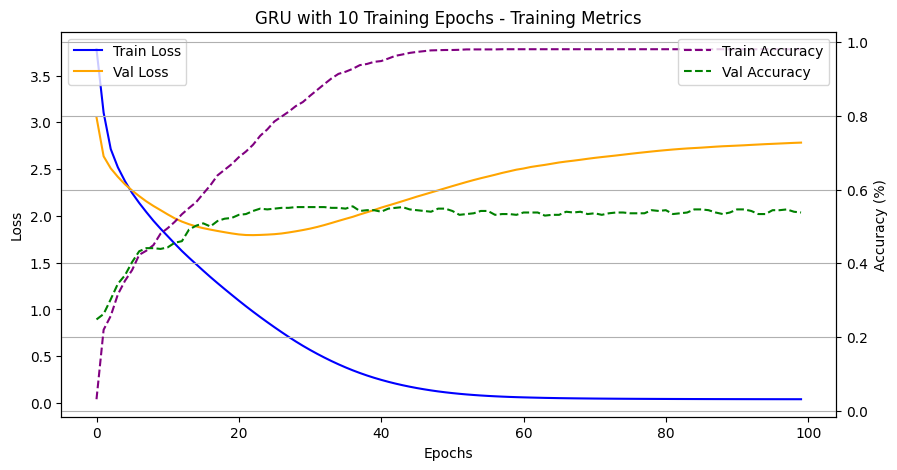

417324
GRU Model with 20 Sequence Length
Epoch 1/100| Time: 0.28s| Training Loss: 3.8016| Training Accuracy: 0.0164| Validation Loss: 3.1515| Validation Accuracy: 0.2489
Epoch 2/100| Time: 0.29s| Training Loss: 3.1291| Training Accuracy: 0.2616| Validation Loss: 2.7304| Validation Accuracy: 0.2426
Epoch 3/100| Time: 0.29s| Training Loss: 2.7264| Training Accuracy: 0.2595| Validation Loss: 2.5850| Validation Accuracy: 0.2785
Epoch 4/100| Time: 0.28s| Training Loss: 2.5698| Training Accuracy: 0.3092| Validation Loss: 2.4283| Validation Accuracy: 0.2975
Epoch 5/100| Time: 0.28s| Training Loss: 2.3963| Training Accuracy: 0.3266| Validation Loss: 2.3445| Validation Accuracy: 0.3397
Epoch 6/100| Time: 0.29s| Training Loss: 2.2871| Training Accuracy: 0.3594| Validation Loss: 2.2643| Validation Accuracy: 0.3692
Epoch 7/100| Time: 0.28s| Training Loss: 2.1758| Training Accuracy: 0.3953| Validation Loss: 2.1931| Validation Accuracy: 0.4051
Epoch 8/100| Time: 0.28s| Training Loss: 2.0705| Trainin

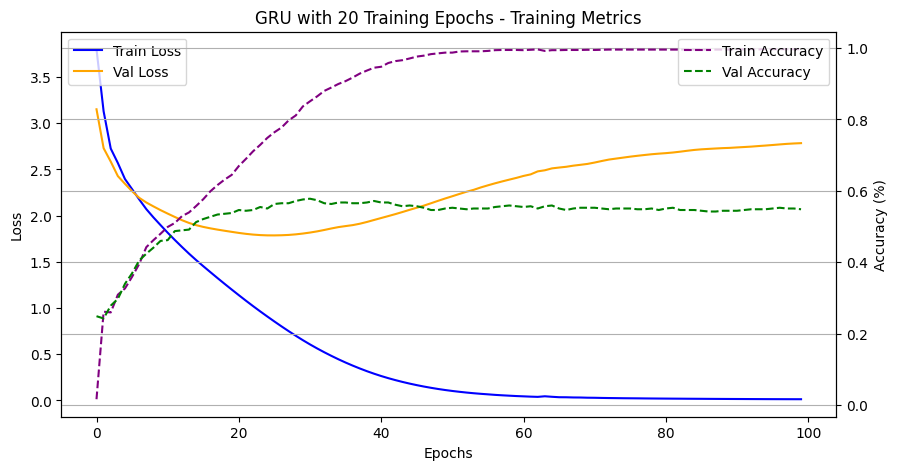

417324
GRU Model with 30 Sequence Length
Epoch 1/100| Time: 0.42s| Training Loss: 3.7979| Training Accuracy: 0.0175| Validation Loss: 3.1689| Validation Accuracy: 0.2119
Epoch 2/100| Time: 0.41s| Training Loss: 3.1170| Training Accuracy: 0.2266| Validation Loss: 2.7971| Validation Accuracy: 0.2479
Epoch 3/100| Time: 0.42s| Training Loss: 2.7435| Training Accuracy: 0.2473| Validation Loss: 2.6654| Validation Accuracy: 0.2627
Epoch 4/100| Time: 0.39s| Training Loss: 2.5720| Training Accuracy: 0.2909| Validation Loss: 2.5463| Validation Accuracy: 0.2797
Epoch 5/100| Time: 0.40s| Training Loss: 2.4187| Training Accuracy: 0.3461| Validation Loss: 2.4358| Validation Accuracy: 0.3220
Epoch 6/100| Time: 0.43s| Training Loss: 2.2855| Training Accuracy: 0.3657| Validation Loss: 2.3562| Validation Accuracy: 0.3496
Epoch 7/100| Time: 0.42s| Training Loss: 2.1818| Training Accuracy: 0.3880| Validation Loss: 2.3006| Validation Accuracy: 0.3814
Epoch 8/100| Time: 0.42s| Training Loss: 2.0924| Trainin

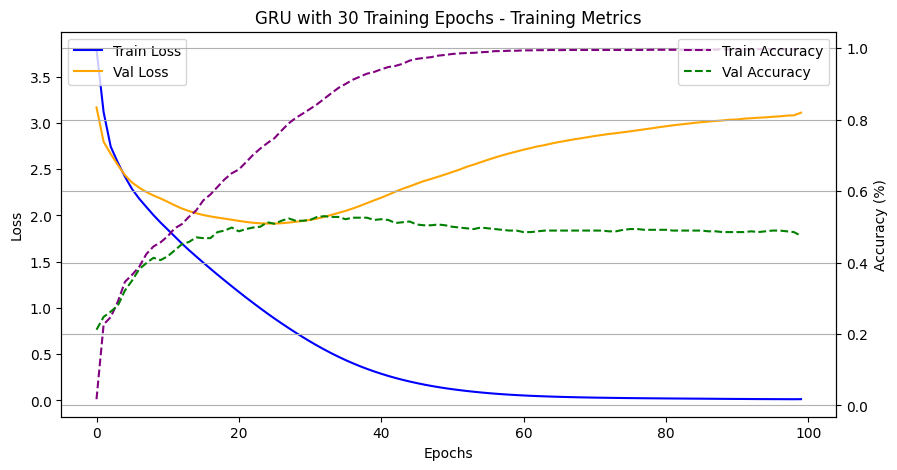

In [17]:
# Defining the GRU model
class CharGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharGRU, self).__init__()
        self.hidden_size = hidden_size
        #This line takes the input tensor x, which contains indices of characters, and passes it through an embedding layer (self.embedding).
        #The embedding layer converts these indices into dense vectors of fixed size.
        #These vectors are learned during training and can capture semantic similarities between characters.
        #The result is a higher-dimensional representation of the input sequence, where each character index is replaced by its corresponding embedding vector.
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        #The RNN layer returns two outputs:
        #1- the output tensor containing the output of the RNN at each time step for each sequence in the batch,
        #2-the hidden state (_) of the last time step (which is not used in this line, hence the underscore).
        output, _ = self.rnn(embedded)
        #The RNN's output contains the outputs for every time step,
        #but for this task, we're only interested in the output of the last time step because we're predicting the next character after the sequence.
        #output[:, -1, :] selects the last time step's output for every sequence in the batch (-1 indexes the last item in Python).
        output = self.fc(output[:, -1, :])  # Get the output of the last RNN cell
        return output
for x in seq_length:
  model = CharGRU(len(chars), hidden_size, len(chars))
  model.name = "GRU"
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  count_parameters(model)
  X_train, y_train, X_val, y_val = prepare_data(text, x)
  train(model, criterion, optimizer, X_train, y_train, X_val, y_val, epochs, x)

Smaller Hidden Layer Size

In [18]:
# Defining the RNN model
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        #This line takes the input tensor x, which contains indices of characters, and passes it through an embedding layer (self.embedding).
        #The embedding layer converts these indices into dense vectors of fixed size.
        #These vectors are learned during training and can capture semantic similarities between characters.
        #The result is a higher-dimensional representation of the input sequence, where each character index is replaced by its corresponding embedding vector.
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        #The RNN layer returns two outputs:
        #1- the output tensor containing the output of the RNN at each time step for each sequence in the batch,
        #2-the hidden state (_) of the last time step (which is not used in this line, hence the underscore).
        output, _ = self.rnn(embedded)
        #The RNN's output contains the outputs for every time step,
        #but for this task, we're only interested in the output of the last time step because we're predicting the next character after the sequence.
        #output[:, -1, :] selects the last time step's output for every sequence in the batch (-1 indexes the last item in Python).
        output = self.fc(output[:, -1, :])  # Get the output of the last RNN cell
        return output

class CharLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharLSTM, self).__init__()
        self.hidden_size = hidden_size
        #This line takes the input tensor x, which contains indices of characters, and passes it through an embedding layer (self.embedding).
        #The embedding layer converts these indices into dense vectors of fixed size.
        #These vectors are learned during training and can capture semantic similarities between characters.
        #The result is a higher-dimensional representation of the input sequence, where each character index is replaced by its corresponding embedding vector.
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        #The RNN layer returns two outputs:
        #1- the output tensor containing the output of the RNN at each time step for each sequence in the batch,
        #2-the hidden state (_) of the last time step (which is not used in this line, hence the underscore).
        output, _ = self.rnn(embedded)
        #The RNN's output contains the outputs for every time step,
        #but for this task, we're only interested in the output of the last time step because we're predicting the next character after the sequence.
        #output[:, -1, :] selects the last time step's output for every sequence in the batch (-1 indexes the last item in Python).
        output = self.fc(output[:, -1, :])  # Get the output of the last RNN cell
        return output

class CharGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharGRU, self).__init__()
        self.hidden_size = hidden_size
        #This line takes the input tensor x, which contains indices of characters, and passes it through an embedding layer (self.embedding).
        #The embedding layer converts these indices into dense vectors of fixed size.
        #These vectors are learned during training and can capture semantic similarities between characters.
        #The result is a higher-dimensional representation of the input sequence, where each character index is replaced by its corresponding embedding vector.
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        #The RNN layer returns two outputs:
        #1- the output tensor containing the output of the RNN at each time step for each sequence in the batch,
        #2-the hidden state (_) of the last time step (which is not used in this line, hence the underscore).
        output, _ = self.rnn(embedded)
        #The RNN's output contains the outputs for every time step,
        #but for this task, we're only interested in the output of the last time step because we're predicting the next character after the sequence.
        #output[:, -1, :] selects the last time step's output for every sequence in the batch (-1 indexes the last item in Python).
        output = self.fc(output[:, -1, :])  # Get the output of the last RNN cell
        return output

44332
RNN Model with 10 Sequence Length
Epoch 1/100| Time: 0.02s| Training Loss: 3.8111| Training Accuracy: 0.0158| Validation Loss: 3.4153| Validation Accuracy: 0.1870
Epoch 2/100| Time: 0.02s| Training Loss: 3.4067| Training Accuracy: 0.2216| Validation Loss: 3.0571| Validation Accuracy: 0.2962
Epoch 3/100| Time: 0.02s| Training Loss: 3.0490| Training Accuracy: 0.3037| Validation Loss: 2.7460| Validation Accuracy: 0.2920
Epoch 4/100| Time: 0.02s| Training Loss: 2.7562| Training Accuracy: 0.3005| Validation Loss: 2.5751| Validation Accuracy: 0.2983
Epoch 5/100| Time: 0.02s| Training Loss: 2.6020| Training Accuracy: 0.3111| Validation Loss: 2.4846| Validation Accuracy: 0.3004
Epoch 6/100| Time: 0.02s| Training Loss: 2.5080| Training Accuracy: 0.3095| Validation Loss: 2.4150| Validation Accuracy: 0.3109
Epoch 7/100| Time: 0.02s| Training Loss: 2.4199| Training Accuracy: 0.3174| Validation Loss: 2.3592| Validation Accuracy: 0.3466
Epoch 8/100| Time: 0.02s| Training Loss: 2.3373| Training

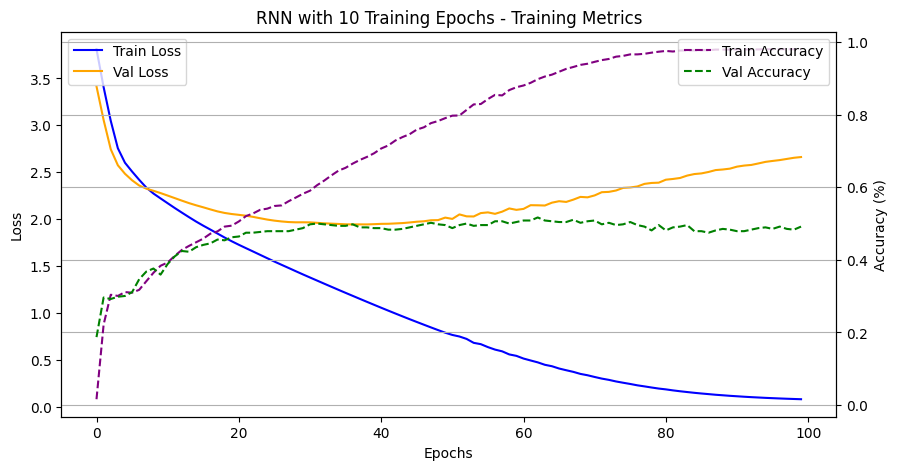

44332
RNN Model with 20 Sequence Length
Epoch 1/100| Time: 0.03s| Training Loss: 3.8323| Training Accuracy: 0.0106| Validation Loss: 3.4488| Validation Accuracy: 0.2089
Epoch 2/100| Time: 0.03s| Training Loss: 3.4166| Training Accuracy: 0.2008| Validation Loss: 3.0659| Validation Accuracy: 0.2574
Epoch 3/100| Time: 0.03s| Training Loss: 3.0315| Training Accuracy: 0.2574| Validation Loss: 2.8007| Validation Accuracy: 0.2405
Epoch 4/100| Time: 0.03s| Training Loss: 2.7940| Training Accuracy: 0.2431| Validation Loss: 2.6714| Validation Accuracy: 0.2785
Epoch 5/100| Time: 0.03s| Training Loss: 2.6654| Training Accuracy: 0.2785| Validation Loss: 2.5718| Validation Accuracy: 0.2869
Epoch 6/100| Time: 0.03s| Training Loss: 2.5471| Training Accuracy: 0.3055| Validation Loss: 2.4977| Validation Accuracy: 0.3080
Epoch 7/100| Time: 0.03s| Training Loss: 2.4564| Training Accuracy: 0.3219| Validation Loss: 2.4382| Validation Accuracy: 0.3418
Epoch 8/100| Time: 0.03s| Training Loss: 2.3884| Training

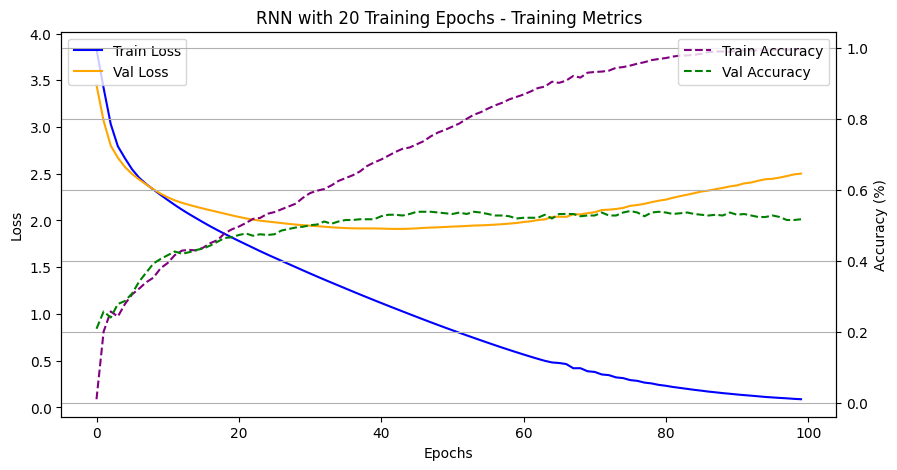

44332
RNN Model with 30 Sequence Length
Epoch 1/100| Time: 0.06s| Training Loss: 3.8016| Training Accuracy: 0.0180| Validation Loss: 3.4171| Validation Accuracy: 0.1928
Epoch 2/100| Time: 0.05s| Training Loss: 3.3939| Training Accuracy: 0.2272| Validation Loss: 3.0744| Validation Accuracy: 0.2860
Epoch 3/100| Time: 0.05s| Training Loss: 3.0154| Training Accuracy: 0.2999| Validation Loss: 2.8072| Validation Accuracy: 0.2648
Epoch 4/100| Time: 0.05s| Training Loss: 2.7483| Training Accuracy: 0.2797| Validation Loss: 2.7053| Validation Accuracy: 0.2669
Epoch 5/100| Time: 0.06s| Training Loss: 2.6431| Training Accuracy: 0.2872| Validation Loss: 2.6199| Validation Accuracy: 0.2966
Epoch 6/100| Time: 0.07s| Training Loss: 2.5297| Training Accuracy: 0.3232| Validation Loss: 2.5457| Validation Accuracy: 0.3178
Epoch 7/100| Time: 0.07s| Training Loss: 2.4243| Training Accuracy: 0.3471| Validation Loss: 2.4915| Validation Accuracy: 0.3136
Epoch 8/100| Time: 0.07s| Training Loss: 2.3481| Training

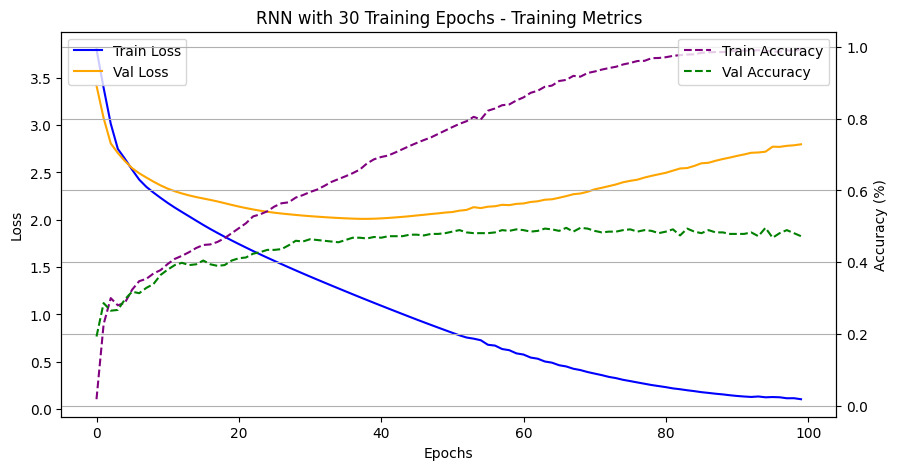

143404
LSTM Model with 10 Sequence Length
Epoch 1/100| Time: 0.06s| Training Loss: 3.7905| Training Accuracy: 0.0116| Validation Loss: 3.5971| Validation Accuracy: 0.1870
Epoch 2/100| Time: 0.05s| Training Loss: 3.6033| Training Accuracy: 0.1732| Validation Loss: 3.3604| Validation Accuracy: 0.2311
Epoch 3/100| Time: 0.05s| Training Loss: 3.3738| Training Accuracy: 0.1974| Validation Loss: 3.0588| Validation Accuracy: 0.1933
Epoch 4/100| Time: 0.06s| Training Loss: 3.0895| Training Accuracy: 0.1800| Validation Loss: 2.8701| Validation Accuracy: 0.1870
Epoch 5/100| Time: 0.05s| Training Loss: 2.9264| Training Accuracy: 0.1668| Validation Loss: 2.7820| Validation Accuracy: 0.2038
Epoch 6/100| Time: 0.05s| Training Loss: 2.8558| Training Accuracy: 0.1942| Validation Loss: 2.6953| Validation Accuracy: 0.2815
Epoch 7/100| Time: 0.05s| Training Loss: 2.7671| Training Accuracy: 0.2653| Validation Loss: 2.6249| Validation Accuracy: 0.2899
Epoch 8/100| Time: 0.06s| Training Loss: 2.6778| Traini

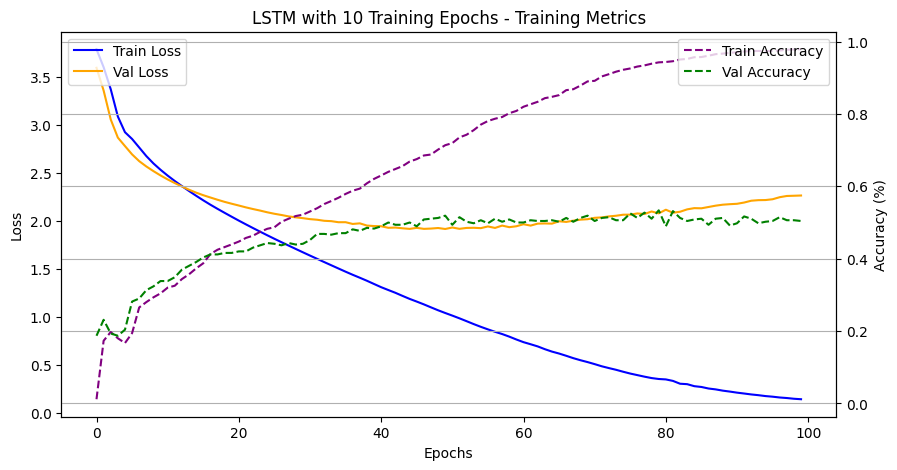

143404
LSTM Model with 20 Sequence Length
Epoch 1/100| Time: 0.18s| Training Loss: 3.8000| Training Accuracy: 0.0201| Validation Loss: 3.6157| Validation Accuracy: 0.1835
Epoch 2/100| Time: 0.18s| Training Loss: 3.6088| Training Accuracy: 0.2019| Validation Loss: 3.3862| Validation Accuracy: 0.2194
Epoch 3/100| Time: 0.15s| Training Loss: 3.3808| Training Accuracy: 0.2204| Validation Loss: 3.0812| Validation Accuracy: 0.1899
Epoch 4/100| Time: 0.13s| Training Loss: 3.0882| Training Accuracy: 0.1860| Validation Loss: 2.8951| Validation Accuracy: 0.1709
Epoch 5/100| Time: 0.12s| Training Loss: 2.9262| Training Accuracy: 0.1702| Validation Loss: 2.8053| Validation Accuracy: 0.2025
Epoch 6/100| Time: 0.12s| Training Loss: 2.8362| Training Accuracy: 0.2045| Validation Loss: 2.7271| Validation Accuracy: 0.2890
Epoch 7/100| Time: 0.12s| Training Loss: 2.7453| Training Accuracy: 0.2875| Validation Loss: 2.6660| Validation Accuracy: 0.2827
Epoch 8/100| Time: 0.12s| Training Loss: 2.6721| Traini

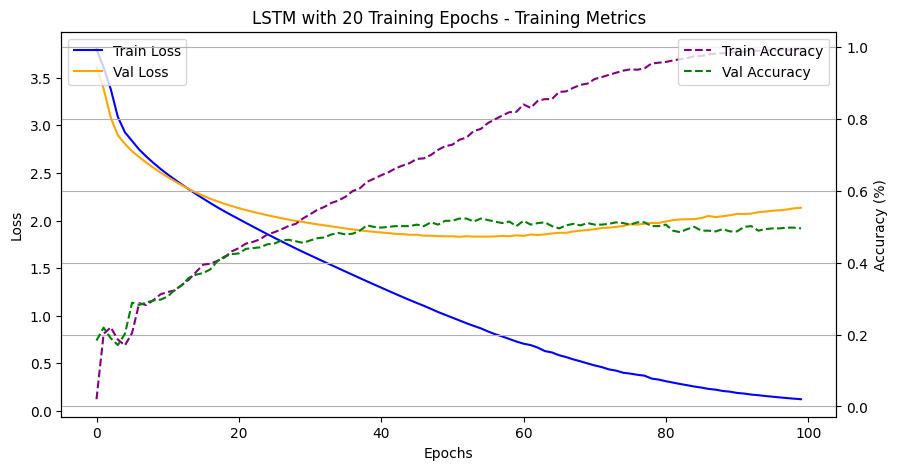

143404
LSTM Model with 30 Sequence Length
Epoch 1/100| Time: 0.17s| Training Loss: 3.8011| Training Accuracy: 0.0074| Validation Loss: 3.6435| Validation Accuracy: 0.1928
Epoch 2/100| Time: 0.18s| Training Loss: 3.6257| Training Accuracy: 0.2139| Validation Loss: 3.4428| Validation Accuracy: 0.2331
Epoch 3/100| Time: 0.17s| Training Loss: 3.4091| Training Accuracy: 0.2585| Validation Loss: 3.1577| Validation Accuracy: 0.2182
Epoch 4/100| Time: 0.17s| Training Loss: 3.1127| Training Accuracy: 0.2489| Validation Loss: 2.9329| Validation Accuracy: 0.1864
Epoch 5/100| Time: 0.17s| Training Loss: 2.8923| Training Accuracy: 0.2038| Validation Loss: 2.8656| Validation Accuracy: 0.1992
Epoch 6/100| Time: 0.18s| Training Loss: 2.8298| Training Accuracy: 0.2139| Validation Loss: 2.7746| Validation Accuracy: 0.2394
Epoch 7/100| Time: 0.17s| Training Loss: 2.7294| Training Accuracy: 0.2516| Validation Loss: 2.6885| Validation Accuracy: 0.2669
Epoch 8/100| Time: 0.20s| Training Loss: 2.6297| Traini

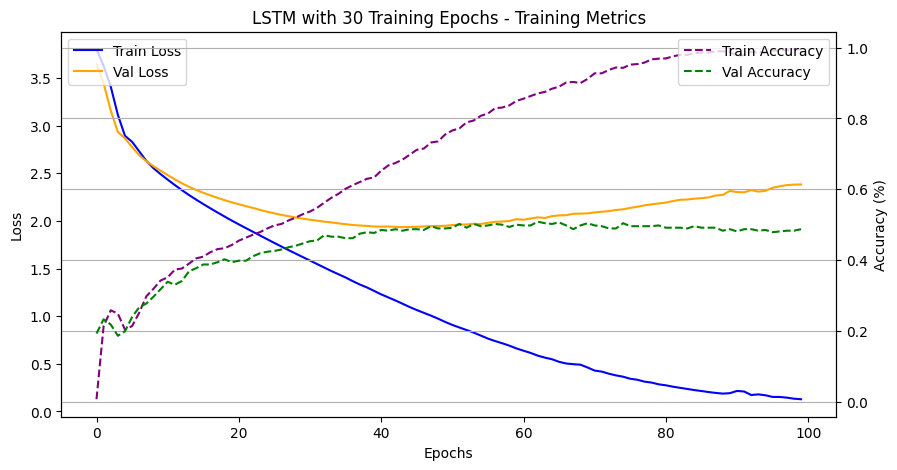

110380
GRU Model with 10 Sequence Length
Epoch 1/100| Time: 0.04s| Training Loss: 3.8223| Training Accuracy: 0.0195| Validation Loss: 3.4904| Validation Accuracy: 0.1870
Epoch 2/100| Time: 0.04s| Training Loss: 3.5110| Training Accuracy: 0.1716| Validation Loss: 3.1760| Validation Accuracy: 0.2542
Epoch 3/100| Time: 0.04s| Training Loss: 3.2088| Training Accuracy: 0.2284| Validation Loss: 2.8821| Validation Accuracy: 0.2521
Epoch 4/100| Time: 0.04s| Training Loss: 2.9341| Training Accuracy: 0.2221| Validation Loss: 2.7327| Validation Accuracy: 0.2689
Epoch 5/100| Time: 0.05s| Training Loss: 2.7980| Training Accuracy: 0.2400| Validation Loss: 2.6591| Validation Accuracy: 0.2668
Epoch 6/100| Time: 0.04s| Training Loss: 2.7150| Training Accuracy: 0.2679| Validation Loss: 2.5947| Validation Accuracy: 0.2878
Epoch 7/100| Time: 0.04s| Training Loss: 2.6290| Training Accuracy: 0.2874| Validation Loss: 2.5316| Validation Accuracy: 0.2962
Epoch 8/100| Time: 0.04s| Training Loss: 2.5425| Trainin

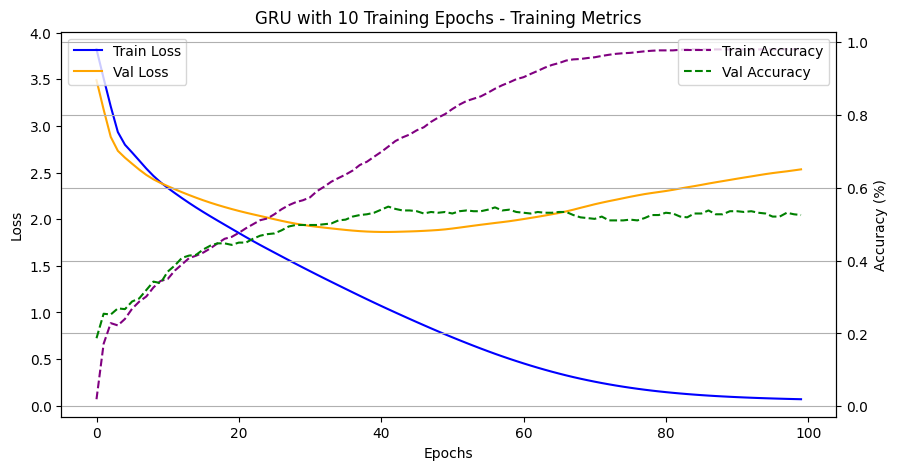

110380
GRU Model with 20 Sequence Length
Epoch 1/100| Time: 0.09s| Training Loss: 3.8112| Training Accuracy: 0.0095| Validation Loss: 3.4887| Validation Accuracy: 0.1962
Epoch 2/100| Time: 0.09s| Training Loss: 3.4619| Training Accuracy: 0.2067| Validation Loss: 3.1664| Validation Accuracy: 0.2110
Epoch 3/100| Time: 0.09s| Training Loss: 3.1370| Training Accuracy: 0.2188| Validation Loss: 2.9090| Validation Accuracy: 0.2089
Epoch 4/100| Time: 0.09s| Training Loss: 2.8879| Training Accuracy: 0.2236| Validation Loss: 2.7757| Validation Accuracy: 0.2363
Epoch 5/100| Time: 0.09s| Training Loss: 2.7633| Training Accuracy: 0.2553| Validation Loss: 2.6739| Validation Accuracy: 0.2468
Epoch 6/100| Time: 0.09s| Training Loss: 2.6601| Training Accuracy: 0.2854| Validation Loss: 2.5945| Validation Accuracy: 0.2637
Epoch 7/100| Time: 0.11s| Training Loss: 2.5732| Training Accuracy: 0.2997| Validation Loss: 2.5284| Validation Accuracy: 0.2827
Epoch 8/100| Time: 0.10s| Training Loss: 2.4999| Trainin

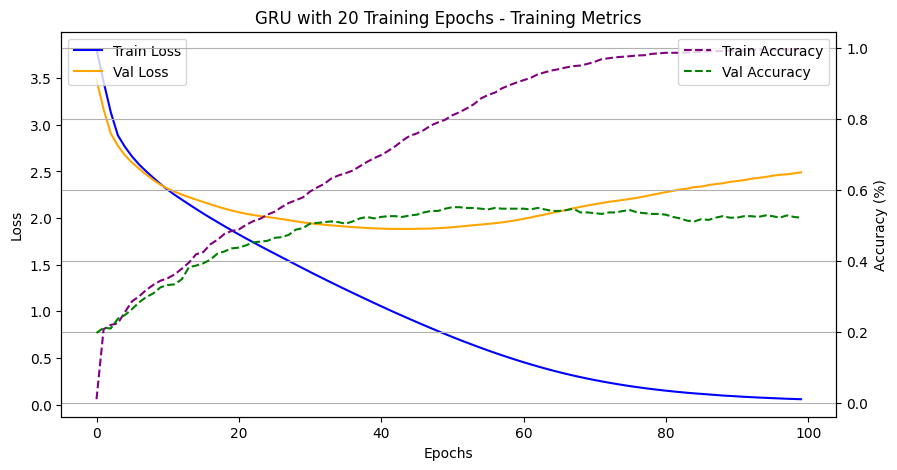

110380
GRU Model with 30 Sequence Length
Epoch 1/100| Time: 0.14s| Training Loss: 3.7931| Training Accuracy: 0.0334| Validation Loss: 3.5044| Validation Accuracy: 0.1864
Epoch 2/100| Time: 0.15s| Training Loss: 3.4798| Training Accuracy: 0.2118| Validation Loss: 3.2141| Validation Accuracy: 0.2182
Epoch 3/100| Time: 0.14s| Training Loss: 3.1730| Training Accuracy: 0.2410| Validation Loss: 2.9508| Validation Accuracy: 0.2246
Epoch 4/100| Time: 0.14s| Training Loss: 2.9016| Training Accuracy: 0.2378| Validation Loss: 2.8171| Validation Accuracy: 0.2352
Epoch 5/100| Time: 0.13s| Training Loss: 2.7743| Training Accuracy: 0.2611| Validation Loss: 2.7256| Validation Accuracy: 0.2775
Epoch 6/100| Time: 0.14s| Training Loss: 2.6864| Training Accuracy: 0.2861| Validation Loss: 2.6514| Validation Accuracy: 0.2775
Epoch 7/100| Time: 0.14s| Training Loss: 2.6006| Training Accuracy: 0.2771| Validation Loss: 2.5885| Validation Accuracy: 0.2860
Epoch 8/100| Time: 0.15s| Training Loss: 2.5155| Trainin

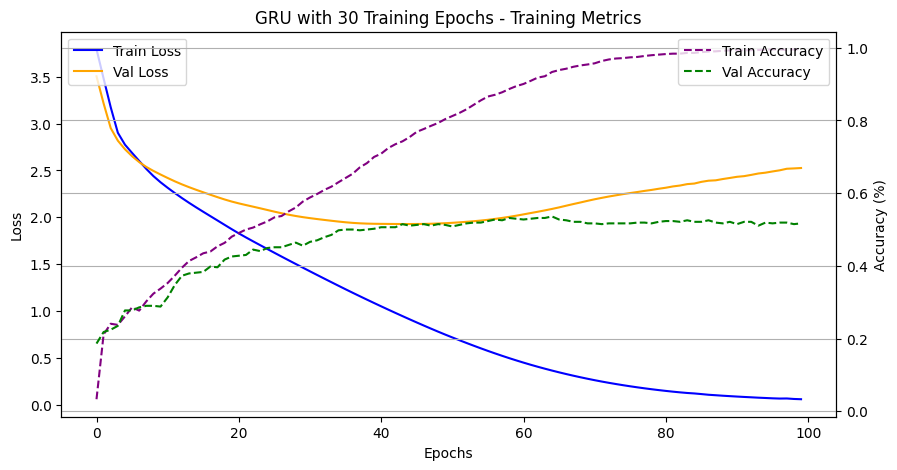

In [19]:
hidden_size = 128

#RNN with Fewer Neurons
# Predicting the next character
seq_length = [10, 20, 30]
for x in seq_length:
  model = CharRNN(len(chars), hidden_size, len(chars))
  model.name = "RNN"
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  count_parameters(model)
  X_train, y_train, X_val, y_val = prepare_data(text, x)
  train(model, criterion, optimizer, X_train, y_train, X_val, y_val, epochs, x)
for x in seq_length:
  model = CharLSTM(len(chars), hidden_size, len(chars))
  model.name = "LSTM"
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  count_parameters(model)
  X_train, y_train, X_val, y_val = prepare_data(text, x)
  train(model, criterion, optimizer, X_train, y_train, X_val, y_val, epochs, x)
for x in seq_length:
  model = CharGRU(len(chars), hidden_size, len(chars))
  model.name = "GRU"
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)
  count_parameters(model)
  X_train, y_train, X_val, y_val = prepare_data(text, x)
  train(model, criterion, optimizer, X_train, y_train, X_val, y_val, epochs, x)

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import requests

# Step 1: Download the dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text  # This is the entire text data

# Step 2: Prepare the dataset
sequence_length = 20
# Create a character mapping to integers
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode the text into integers
encoded_text = [char_to_int[ch] for ch in text]

# Create sequences and targets
sequences = []
targets = []
for i in range(0, len(encoded_text) - sequence_length):
    seq = encoded_text[i:i+sequence_length]
    target = encoded_text[i+sequence_length]
    sequences.append(seq)
    targets.append(target)

# Convert lists to PyTorch tensors
sequences = torch.tensor(sequences, dtype=torch.long)
targets = torch.tensor(targets, dtype=torch.long)

# Step 3: Create a dataset class
class CharDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        return self.sequences[index], self.targets[index]

# Instantiate the dataset
dataset = CharDataset(sequences, targets)

# Step 4: Create data loaders
batch_size = 128
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)

# Now `train_loader` and `test_loader` are ready to be used in a training loop

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import requests
from torch.optim import lr_scheduler
import time

class ShakespeareModel(nn.Module):
    def __init__(self, cell_type, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super(ShakespeareModel, self).__init__()
        self.cell_type = cell_type.upper()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        if self.cell_type == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        elif self.cell_type == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers, batch_first=True)
        else:
            raise ValueError("Choose 'LSTM' or 'GRU'")

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        out = self.embedding(x)
        out, hidden = self.rnn(out, hidden)
        # Sequence-to-one mapping: classify using the last time-step hidden state
        out = self.fc(out[:, -1, :])
        return out, hidden

def generate_text(model, start_str, length=100, device='cpu'):
    model.eval()
    generated = start_str
    input_seq = [char_to_int[ch] for ch in start_str]

    with torch.no_grad():
        for _ in range(length):
            # Pad or slice the seed sequence to match training expectations
            X_curr = torch.tensor([input_seq], dtype=torch.long).to(device)
            output, _ = model(X_curr)
            pred_idx = torch.argmax(output, dim=-1).item()

            generated += int_to_char[pred_idx]
            input_seq.append(pred_idx)
            input_seq = input_seq[1:] # slide window

    return generated

def run_experiment(cell_type, seq_len, embed_dim, hidden_dim, num_layers, epochs=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Generate sequences and targets for the current seq_len
    current_sequences = []
    current_targets = []
    for i in range(0, len(encoded_text) - seq_len):
        seq = encoded_text[i:i + seq_len]
        target = encoded_text[i + seq_len]
        current_sequences.append(seq)
        current_targets.append(target)

    # Convert to PyTorch tensors
    current_sequences = torch.tensor(current_sequences, dtype=torch.long)
    current_targets = torch.tensor(current_targets, dtype=torch.long)

    # Dynamic loader assignment for specific sequence lengths
    ds = CharDataset(current_sequences, current_targets)
    train_size = int(len(ds) * 0.8)
    val_size = len(ds) - train_size
    train_ds, val_ds = random_split(ds, [train_size, val_size])

    t_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    v_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

    model = ShakespeareModel(cell_type, vocab_size, embed_dim, hidden_dim, num_layers).to(device)
    model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.003)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5) # Add learning rate scheduler

    print(f"\nTraining {cell_type} | Seq Len: {seq_len} | Hidden: {hidden_dim} | Layers: {num_layers} | Params: {model_size:,}")

    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        for x_b, y_b in t_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            outputs, _ = model(x_b)
            loss = criterion(outputs, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=-1)
            train_correct += (preds == y_b).sum().item()
            train_total += y_b.numel()

        scheduler.step() # Step the scheduler after each epoch

        # Optional validation per epoch to track progress
        avg_train_loss = train_loss / len(t_loader)
        avg_train_acc = train_correct / train_total

        exec_time = time.time() - start_time

        # Comprehensive Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for x_b, y_b in v_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                outputs, _ = model(x_b)
                loss = criterion(outputs, y_b)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=-1)
                correct += (preds == y_b).sum().item()
                total += y_b.numel()

        avg_val_loss = val_loss / len(v_loader)
        val_acc = (correct / total) * 100
        perplexity = np.exp(avg_val_loss)
        print(f"Epoch {epoch:02d}/{epochs}| "
                  f"Time: {exec_time:.2f}s| "
                  f"Training Loss: {avg_train_loss:.4f}| "
                  f"Training Accuracy: {avg_train_acc:.4f}| "
                  f"Validation Loss: {avg_val_loss:.4f}| "
                  f"Validation Accuracy: {val_acc:.4f}")

    # Generate an output sequence
    sample_seed = text[:seq_len] if len(text) > seq_len else "FIRST CITIZEN:"[:seq_len]
    generated_sample = generate_text(model, sample_seed, length=60, device=device)

    print(f"  Execution Time: {exec_time:.2f}s | Val Acc: {val_acc:.2f}% | PPL: {perplexity:.2f}")
    print(f"  Generated Text Sample:\n  \" {generated_sample.replace('\n', ' ')} \"")

    return {
        "cell": cell_type, "seq_len": seq_len, "layers": num_layers, "hidden": hidden_dim,
        "params": model_size, "train_loss": avg_train_loss, "val_loss": avg_val_loss,
        "val_acc": val_acc, "ppl": perplexity, "time": exec_time
    }

# ==========================================
# 4. EXECUTION OF PROBLEM 2 MATRICES
# ==========================================
experiments = [
    # Core Tasks (Seq lengths 20 and 30)
    {"cell": "LSTM", "seq_len": 20, "embed": 64, "hidden": 128, "layers": 1},
    {"cell": "GRU",  "seq_len": 20, "embed": 64, "hidden": 128, "layers": 1},
    {"cell": "LSTM", "seq_len": 30, "embed": 64, "hidden": 128, "layers": 1},
    {"cell": "GRU",  "seq_len": 30, "embed": 64, "hidden": 128, "layers": 1},

    # Hyperparameter Modifications (Capacity Scaling)
    {"cell": "LSTM", "seq_len": 30, "embed": 64, "hidden": 256, "layers": 2},
    {"cell": "GRU", "seq_len": 30, "embed": 64, "hidden": 256, "layers": 2},

    # Extreme Sequence Length (Seq length 50)
    {"cell": "LSTM", "seq_len": 50, "embed": 64, "hidden": 128, "layers": 1},
    {"cell": "GRU",  "seq_len": 50, "embed": 64, "hidden": 128, "layers": 1}
]

results = []
# Standardizing on 3 short epochs for comparison speed; increase for lower loss profiles.
for exp in experiments:
    res = run_experiment(exp["cell"], exp["seq_len"], exp["embed"], exp["hidden"], exp["layers"], epochs=25)
    results.append(res)


Training LSTM | Seq Len: 20 | Hidden: 128 | Layers: 1 | Params: 111,873
Epoch 00/25| Time: 14.26s| Training Loss: 1.7786| Training Accuracy: 0.4750| Validation Loss: 1.5990| Validation Accuracy: 51.9525
Epoch 01/25| Time: 30.42s| Training Loss: 1.5458| Training Accuracy: 0.5333| Validation Loss: 1.5306| Validation Accuracy: 53.5188
Epoch 02/25| Time: 46.57s| Training Loss: 1.4932| Training Accuracy: 0.5460| Validation Loss: 1.5015| Validation Accuracy: 54.3243
Epoch 03/25| Time: 63.12s| Training Loss: 1.4641| Training Accuracy: 0.5535| Validation Loss: 1.4786| Validation Accuracy: 55.0756
Epoch 04/25| Time: 79.48s| Training Loss: 1.4464| Training Accuracy: 0.5579| Validation Loss: 1.4732| Validation Accuracy: 55.3442
Epoch 05/25| Time: 95.60s| Training Loss: 1.3966| Training Accuracy: 0.5713| Validation Loss: 1.4296| Validation Accuracy: 56.4299
Epoch 06/25| Time: 111.72s| Training Loss: 1.3830| Training Accuracy: 0.5746| Validation Loss: 1.4245| Validation Accuracy: 56.5760
Epoch 07/

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import requests
from torch.optim import lr_scheduler
import time

class ShakespeareModel(nn.Module):
    def __init__(self, cell_type, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super(ShakespeareModel, self).__init__()
        self.cell_type = cell_type.upper()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        if self.cell_type == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        elif self.cell_type == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers, batch_first=True)
        else:
            raise ValueError("Choose 'LSTM' or 'GRU'")

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        out = self.embedding(x)
        out, hidden = self.rnn(out, hidden)
        # Sequence-to-one mapping: classify using the last time-step hidden state
        out = self.fc(out[:, -1, :])
        return out, hidden

def generate_text(model, start_str, length=100, device='cpu'):
    model.eval()
    generated = start_str
    input_seq = [char_to_int[ch] for ch in start_str]

    with torch.no_grad():
        for _ in range(length):
            # Pad or slice the seed sequence to match training expectations
            X_curr = torch.tensor([input_seq], dtype=torch.long).to(device)
            output, _ = model(X_curr)
            pred_idx = torch.argmax(output, dim=-1).item()

            generated += int_to_char[pred_idx]
            input_seq.append(pred_idx)
            input_seq = input_seq[1:] # slide window

    return generated

def run_experiment(cell_type, seq_len, embed_dim, hidden_dim, num_layers, epochs=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Generate sequences and targets for the current seq_len
    current_sequences = []
    current_targets = []
    for i in range(0, len(encoded_text) - seq_len):
        seq = encoded_text[i:i + seq_len]
        target = encoded_text[i + seq_len]
        current_sequences.append(seq)
        current_targets.append(target)

    # Convert to PyTorch tensors
    current_sequences = torch.tensor(current_sequences, dtype=torch.long)
    current_targets = torch.tensor(current_targets, dtype=torch.long)

    # Dynamic loader assignment for specific sequence lengths
    ds = CharDataset(current_sequences, current_targets)
    train_size = int(len(ds) * 0.8)
    val_size = len(ds) - train_size
    train_ds, val_ds = random_split(ds, [train_size, val_size])

    t_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    v_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

    model = ShakespeareModel(cell_type, vocab_size, embed_dim, hidden_dim, num_layers).to(device)
    model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.003)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5) # Add learning rate scheduler

    print(f"\nTraining {cell_type} | Seq Len: {seq_len} | Hidden: {hidden_dim} | Layers: {num_layers} | Params: {model_size:,}")

    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        for x_b, y_b in t_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            outputs, _ = model(x_b)
            loss = criterion(outputs, y_b)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=-1)
            train_correct += (preds == y_b).sum().item()
            train_total += y_b.numel()

        scheduler.step() # Step the scheduler after each epoch

        # Optional validation per epoch to track progress
        avg_train_loss = train_loss / len(t_loader)
        avg_train_acc = train_correct / train_total

        exec_time = time.time() - start_time

        # Comprehensive Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for x_b, y_b in v_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                outputs, _ = model(x_b)
                loss = criterion(outputs, y_b)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=-1)
                correct += (preds == y_b).sum().item()
                total += y_b.numel()

        avg_val_loss = val_loss / len(v_loader)
        val_acc = (correct / total) * 100
        perplexity = np.exp(avg_val_loss)
        print(f"Epoch {epoch:02d}/{epochs}| "
                  f"Time: {exec_time:.2f}s| "
                  f"Training Loss: {avg_train_loss:.4f}| "
                  f"Training Accuracy: {avg_train_acc:.4f}| "
                  f"Validation Loss: {avg_val_loss:.4f}| "
                  f"Validation Accuracy: {val_acc:.4f}")

    # Generate an output sequence
    sample_seed = text[:seq_len] if len(text) > seq_len else "FIRST CITIZEN:"[:seq_len]
    generated_sample = generate_text(model, sample_seed, length=60, device=device)

    print(f"  Execution Time: {exec_time:.2f}s | Val Acc: {val_acc:.2f}% | PPL: {perplexity:.2f}")
    print(f"  Generated Text Sample:\n  \" {generated_sample.replace('\n', ' ')} \"")

    return {
        "cell": cell_type, "seq_len": seq_len, "layers": num_layers, "hidden": hidden_dim,
        "params": model_size, "train_loss": avg_train_loss, "val_loss": avg_val_loss,
        "val_acc": val_acc, "ppl": perplexity, "time": exec_time
    }

# ==========================================
# 4. EXECUTION OF PROBLEM 2 MATRICES
# ==========================================
experiments = [
    # Core Tasks (Seq lengths 20 and 30)
    {"cell": "LSTM", "seq_len": 30, "embed": 64, "hidden": 128, "layers": 2},
    {"cell": "GRU",  "seq_len": 30, "embed": 64, "hidden": 128, "layers": 2},


    # Extreme Sequence Length (Seq length 50)
    {"cell": "LSTM", "seq_len": 50, "embed": 64, "hidden": 128, "layers": 1},
    {"cell": "GRU",  "seq_len": 50, "embed": 64, "hidden": 128, "layers": 1}
]

results = []
# Standardizing on 3 short epochs for comparison speed; increase for lower loss profiles.
for exp in experiments:
    res = run_experiment(exp["cell"], exp["seq_len"], exp["embed"], exp["hidden"], exp["layers"], epochs=25)
    results.append(res)


Training LSTM | Seq Len: 30 | Hidden: 128 | Layers: 2 | Params: 243,969
Epoch 00/25| Time: 15.13s| Training Loss: 1.7322| Training Accuracy: 0.4889| Validation Loss: 1.5214| Validation Accuracy: 54.0729
Epoch 01/25| Time: 33.21s| Training Loss: 1.4758| Training Accuracy: 0.5507| Validation Loss: 1.4575| Validation Accuracy: 55.7351
Epoch 02/25| Time: 51.06s| Training Loss: 1.4221| Training Accuracy: 0.5634| Validation Loss: 1.4283| Validation Accuracy: 56.2879
Epoch 03/25| Time: 69.06s| Training Loss: 1.3949| Training Accuracy: 0.5698| Validation Loss: 1.4130| Validation Accuracy: 56.8047
Epoch 04/25| Time: 87.30s| Training Loss: 1.3757| Training Accuracy: 0.5751| Validation Loss: 1.4017| Validation Accuracy: 57.2230
Epoch 05/25| Time: 105.10s| Training Loss: 1.3189| Training Accuracy: 0.5900| Validation Loss: 1.3571| Validation Accuracy: 58.2518
Epoch 06/25| Time: 123.12s| Training Loss: 1.2997| Training Accuracy: 0.5945| Validation Loss: 1.3513| Validation Accuracy: 58.5230
Epoch 07

KeyboardInterrupt: 